# Wine Quality Comparative Analysis

## 1. Project Overview

This project performs an exploratory statistical analysis on a wine dataset in order to compare physicochemical properties between wines classified as above-average and below-average in terms of quality.

The analysis is based on partitioning the dataset using the global mean of the quality variable and then comparing feature-wise statistical summaries.

---

## 2. Dataset Formalization

Let the dataset be defined as:

$D = \{x_i, y_i\}_{i=1}^{n}$

where:
- $x_i \in \mathbb{R}^{11}$ represents the physicochemical feature vector
- $y_i \in \mathbb{R}$ represents the wine quality score

---

## 3. Average Quality Definition

The global average quality is defined as:

$\bar{y} = \frac{1}{n} \sum_{i=1}^{n} y_i$

This threshold is used to define two disjoint subsets:

- Above-average group: $D^+ = \{(x_i, y_i) \mid y_i > \bar{y}\}$
- Below-average group: $D^- = \{(x_i, y_i) \mid y_i < \bar{y}\}$

---

## 4. Feature-Wise Statistical Analysis

For each feature $j$, the group-wise mean is computed as:

$\mu_j^+ = \frac{1}{|D^+|} \sum_{x_i \in D^+} x_{i,j}$

$\mu_j^- = \frac{1}{|D^-|} \sum_{x_i \in D^-} x_{i,j}$

The difference between groups is:

$\Delta_j = \mu_j^+ - \mu_j^-$

This value quantifies the direction and magnitude of separation between the two distributions.

---

## 5. Variance and Dispersion

To evaluate variability within each group:

$\sigma_j^{2,+} = \frac{1}{|D^+|} \sum_{x_i \in D^+} (x_{i,j} - \mu_j^+)^2$

$\sigma_j^{2,-} = \frac{1}{|D^-|} \sum_{x_i \in D^-} (x_{i,j} - \mu_j^-)^2$

Standard deviation:

$\sigma_j = \sqrt{\sigma_j^2}$

---

## 6. Standardization (Optional Interpretation Layer)

Feature normalization can be expressed as:

$z_{i,j} = \frac{x_{i,j} - \mu_j}{\sigma_j}$

This transformation ensures scale invariance across heterogeneous chemical features.

---

## 7. Effect Size Estimation

A normalized measure of separation between groups can be expressed using Cohen’s d:

$d_j = \frac{\mu_j^+ - \mu_j^-}{s_j}$

where pooled standard deviation is:

$s_j = \sqrt{\frac{\sigma_j^{2,+} + \sigma_j^{2,-}}{2}}$

---

## 8. Statistical Interpretation

The comparison between groups can be interpreted as a hypothesis structure:

$H_0: \mu_j^+ = \mu_j^-$

$H_1: \mu_j^+ \neq \mu_j^-$

A stronger separation implies higher discriminative power of feature $j$ with respect to wine quality.

---

## 9. Visualization Model

The plotted values correspond to:

$\mathbf{\mu}^+ = (\mu_1^+, \mu_2^+, ..., \mu_{11}^+)$

$\mathbf{\mu}^- = (\mu_1^-, \mu_2^-, ..., \mu_{11}^-)$

The horizontal bar chart visualizes the mapping:

$f: \mathbb{R}^{11} \rightarrow \mathbb{R}^{11}$

where each axis represents a chemical feature projection.

---

## 10. Interpretation Criteria

A feature is considered relevant if:

$|\Delta_j| \gg 0$

or equivalently if:

$|d_j| > \tau$

for some threshold $\tau$ (commonly $\tau \in [0.2, 0.8]$ depending on sensitivity requirements).

---

## 11. Computational Pipeline

The implemented workflow follows:

1. Data preprocessing:
   $x_{i,j} \leftarrow \text{clean}(x_{i,j})$

2. Thresholding:
   $y_i \rightarrow \mathbb{I}(y_i > \bar{y})$

3. Group separation:
   $D \rightarrow (D^+, D^-)$

4. Feature aggregation:
   $\{x_{i,j}\} \rightarrow (\mu_j^+, \mu_j^-)$

5. Visualization:
   $(\mu_j^+, \mu_j^-) \rightarrow \text{bar plot}$

---

## 12. Conclusion

The analysis provides a structured statistical decomposition of wine chemical properties conditioned on quality segmentation.

The main output of the study is the vector of feature differentials:

$\Delta = (\Delta_1, \Delta_2, ..., \Delta_{11})$

which can be directly used for feature selection or as input for predictive modeling frameworks such as regression or classification models.

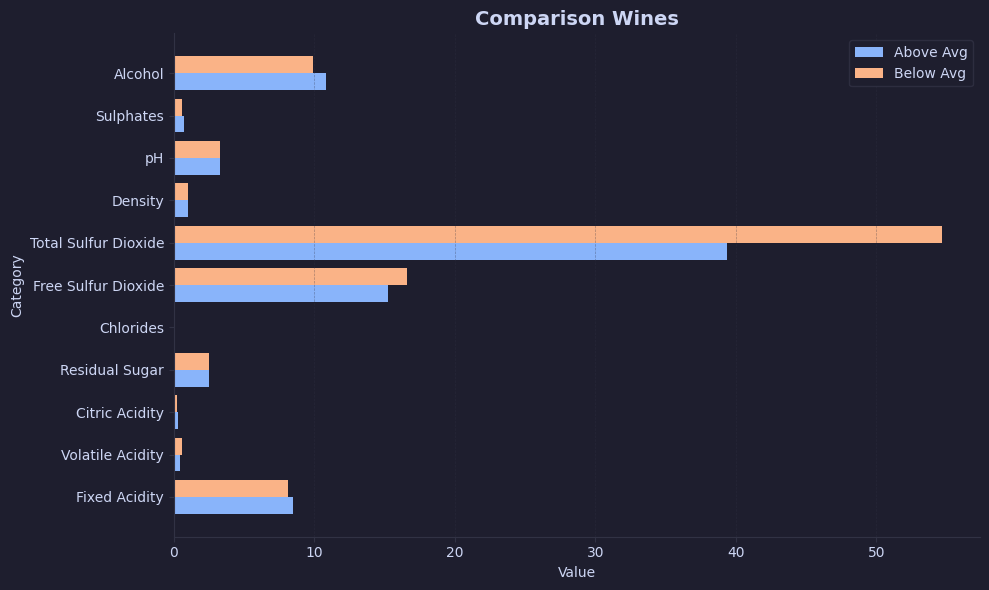

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import catppuccin

df = pd.read_csv("dataset.csv", sep=";")

df.columns = df.columns.str.strip().str.replace('"', '').str.lower()

quality = df["quality"].values

avg_quality = quality.mean()

abv_avg_quality = df[df["quality"] > avg_quality]
bel_avg_quality = df[df["quality"] < avg_quality]


avg_fixed_acidity_abv_avg = abv_avg_quality["fixed acidity"].mean()
avg_volatile_acidity_abv_avg = abv_avg_quality["volatile acidity"].mean()
avg_citric_acid_abv_avg = abv_avg_quality["citric acid"].mean()
avg_residual_sugar_abv_avg = abv_avg_quality["residual sugar"].mean()
avg_chlorides_abv_avg = abv_avg_quality["chlorides"].mean()
avg_free_sulfur_dioxide_abv_avg = abv_avg_quality["free sulfur dioxide"].mean()
avg_total_sulfur_dioxide_abv_avg = abv_avg_quality["total sulfur dioxide"].mean()
avg_density_abv_avg = abv_avg_quality["density"].mean()
avg_pH_abv_avg = abv_avg_quality["ph"].mean()
avg_sulphates_abv_avg = abv_avg_quality["sulphates"].mean()
avg_alcohol_abv_avg = abv_avg_quality["alcohol"].mean()


avg_fixed_acidity_bel_avg = bel_avg_quality["fixed acidity"].mean()
avg_volatile_acidity_bel_avg = bel_avg_quality["volatile acidity"].mean()
avg_citric_acid_bel_avg = bel_avg_quality["citric acid"].mean()
avg_residual_sugar_bel_avg = bel_avg_quality["residual sugar"].mean()
avg_chlorides_bel_avg = bel_avg_quality["chlorides"].mean()
avg_free_sulfur_dioxide_bel_avg = bel_avg_quality["free sulfur dioxide"].mean()
avg_total_sulfur_dioxide_bel_avg = bel_avg_quality["total sulfur dioxide"].mean()
avg_density_bel_avg = bel_avg_quality["density"].mean()
avg_pH_bel_avg = bel_avg_quality["ph"].mean()
avg_sulphates_bel_avg = bel_avg_quality["sulphates"].mean()
avg_alcohol_bel_avg = bel_avg_quality["alcohol"].mean()


x = [
    "Fixed Acidity", "Volatile Acidity", "Citric Acidity", "Residual Sugar",
    "Chlorides", "Free Sulfur Dioxide", "Total Sulfur Dioxide",
    "Density", "pH", "Sulphates", "Alcohol"
]

y_abv = [
    avg_fixed_acidity_abv_avg, avg_volatile_acidity_abv_avg,
    avg_citric_acid_abv_avg, avg_residual_sugar_abv_avg,
    avg_chlorides_abv_avg, avg_free_sulfur_dioxide_abv_avg,
    avg_total_sulfur_dioxide_abv_avg, avg_density_abv_avg,
    avg_pH_abv_avg, avg_sulphates_abv_avg, avg_alcohol_abv_avg
]

y_bel = [
    avg_fixed_acidity_bel_avg, avg_volatile_acidity_bel_avg,
    avg_citric_acid_bel_avg, avg_residual_sugar_bel_avg,
    avg_chlorides_bel_avg, avg_free_sulfur_dioxide_bel_avg,
    avg_total_sulfur_dioxide_bel_avg, avg_density_bel_avg,
    avg_pH_bel_avg, avg_sulphates_bel_avg, avg_alcohol_bel_avg
]

y_pos = np.arange(len(x))
offset = 0.2

plt.style.use("mocha")
plt.figure(figsize=(10, 6))

plt.barh(y_pos - offset, y_abv, height=0.4, label="Above Avg")
plt.barh(y_pos + offset, y_bel, height=0.4, label="Below Avg")

plt.yticks(y_pos, x)
plt.title("Comparison Wines", fontsize=14, weight='bold')
plt.xlabel("Value")
plt.ylabel("Category")

plt.legend()
plt.grid(axis='x', linestyle='--', alpha=0.4)

for spine in ["top", "right"]:
    plt.gca().spines[spine].set_visible(False)

plt.tight_layout()
plt.show()